In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns 
from datetime import date as dt

In [3]:
df = pd.read_csv("../data/swap_transactions.csv",parse_dates=["timestamp"])
df_swaps = pd.read_csv("../data/stations.csv",parse_dates=["opening_date"])

In [4]:
stations_df = df_swaps.copy()

In [5]:
transactions_df = df.copy()

In [6]:
stations_df

,station_id,station_name,district,latitude,longitude,capacity,opening_date
0,ST001,Adenta,Adenta Municipal,5.7049,-0.1682,24,2024-01-15
1,ST002,Haatso,Ga East,5.6704,-0.1988,20,2024-03-01
2,ST003,Spintex,Tema West,5.6256,-0.1024,28,2023-11-10
3,ST004,Kaneshie,Accra Metro,5.5611,-0.2347,24,2024-02-05
4,ST005,Abelenkpe,Ayawaso West,5.6096,-0.1967,20,2024-04-18


In [7]:
transactions_df

,swap_id,timestamp,station_id,battery_soc_returned,battery_soc_issued,wait_minutes,swap_duration_minutes,batteries_available_before_swap,station_status,downtime_minutes,payment_amount,payment_method,motorcycle_type,service_success
0,SW000001,2026-01-01 06:02:33,ST001,34.1,93.2,0.6,4.5,12,Operational,0,35.45,Mobile Money,Standard,True
1,SW000002,2026-01-01 06:32:12,ST004,41.2,95.9,2.8,3.7,16,Operational,0,38.98,Mobile Money,Delivery,True
2,SW000003,2026-01-01 06:46:12,ST005,24.9,85.8,1.2,2.9,15,Operational,0,32.24,Mobile Money,Standard,True
3,SW000004,2026-01-01 06:50:15,ST004,19.6,91.2,9.6,4.5,24,Operational,0,38.84,Mobile Money,Delivery,True
4,SW000005,2026-01-01 06:59:01,ST004,31.7,95.5,4.7,3.2,19,Operational,0,36.44,Mobile Money,Standard,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,SW029996,2026-06-30 22:42:16,ST002,32.5,100.0,1.9,4.4,8,Operational,0,38.97,Mobile Money,Delivery,True
29996,SW029997,2026-06-30 22:54:17,ST003,5.8,96.6,4.0,3.2,1,Operational,0,36.70,Mobile Money,Standard,True
29997,SW029998,2026-06-30 23:16:49,ST004,17.6,98.3,5.5,4.2,15,Operational,0,37.16,Mobile Money,Delivery,True
29998,SW029999,2026-06-30 23:21:50,ST002,20.6,95.5,1.8,4.3,20,Operational,0,34.94,Mobile Money,Standard,True


In [8]:
transactions_df.columns

Index(['swap_id', 'timestamp', 'station_id', 'battery_soc_returned',
       'battery_soc_issued', 'wait_minutes', 'swap_duration_minutes',
       'batteries_available_before_swap', 'station_status', 'downtime_minutes',
       'payment_amount', 'payment_method', 'motorcycle_type',
       'service_success'],
      dtype='object')

In [9]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   swap_id                          30000 non-null  object        
 1   timestamp                        30000 non-null  datetime64[ns]
 2   station_id                       30000 non-null  object        
 3   battery_soc_returned             30000 non-null  float64       
 4   battery_soc_issued               30000 non-null  float64       
 5   wait_minutes                     30000 non-null  float64       
 6   swap_duration_minutes            30000 non-null  float64       
 7   batteries_available_before_swap  30000 non-null  int64         
 8   station_status                   30000 non-null  object        
 9   downtime_minutes                 30000 non-null  int64         
 10  payment_amount                   30000 non-null  float64  

In [10]:
transactions_df.isna().sum()

swap_id                            0
timestamp                          0
station_id                         0
battery_soc_returned               0
battery_soc_issued                 0
wait_minutes                       0
swap_duration_minutes              0
batteries_available_before_swap    0
station_status                     0
downtime_minutes                   0
payment_amount                     0
payment_method                     0
motorcycle_type                    0
service_success                    0
dtype: int64

In [11]:
transactions_df["swap_id"].duplicated().sum()

np.int64(0)

In [12]:
transactions_df["station_id"].value_counts()

station_id
ST001    7912
ST003    6921
ST004    6196
ST002    4945
ST005    4026
Name: count, dtype: int64

In [13]:
transactions_df["timestamp"] = pd.to_datetime(transactions_df["timestamp"])

In [14]:
transactions_df["date"] = transactions_df["timestamp"].dt.date
transactions_df["hour_number"] = transactions_df["timestamp"].dt.hour
transactions_df["hour"] = transactions_df["timestamp"].dt.strftime("%-I %p")
transactions_df["day"] = transactions_df["timestamp"].dt.day_name()
transactions_df["month"] = transactions_df["timestamp"].dt.month_name()

In [41]:
hour_labels = [
    pd.to_datetime(str(hour), format="%H").strftime("%-I %p")
    for hour in range(24)
]

In [15]:
transactions_df[["timestamp","date","hour","day","month"]].head(3)

,timestamp,date,hour,day,month
0,2026-01-01 06:02:33,2026-01-01,6 AM,Thursday,January
1,2026-01-01 06:32:12,2026-01-01,6 AM,Thursday,January
2,2026-01-01 06:46:12,2026-01-01,6 AM,Thursday,January


Calculating KPI

In [16]:
#total swaps
total_swaps = transactions_df["swap_id"].nunique()
print(f"Total swaps are : {total_swaps}")

Total swaps are : 30000


In [17]:
#Total revenue
total_revenue = transactions_df["payment_amount"].sum()
print(f"Total Revenue made in GHS: {total_revenue}")

Total Revenue made in GHS: 1066165.08


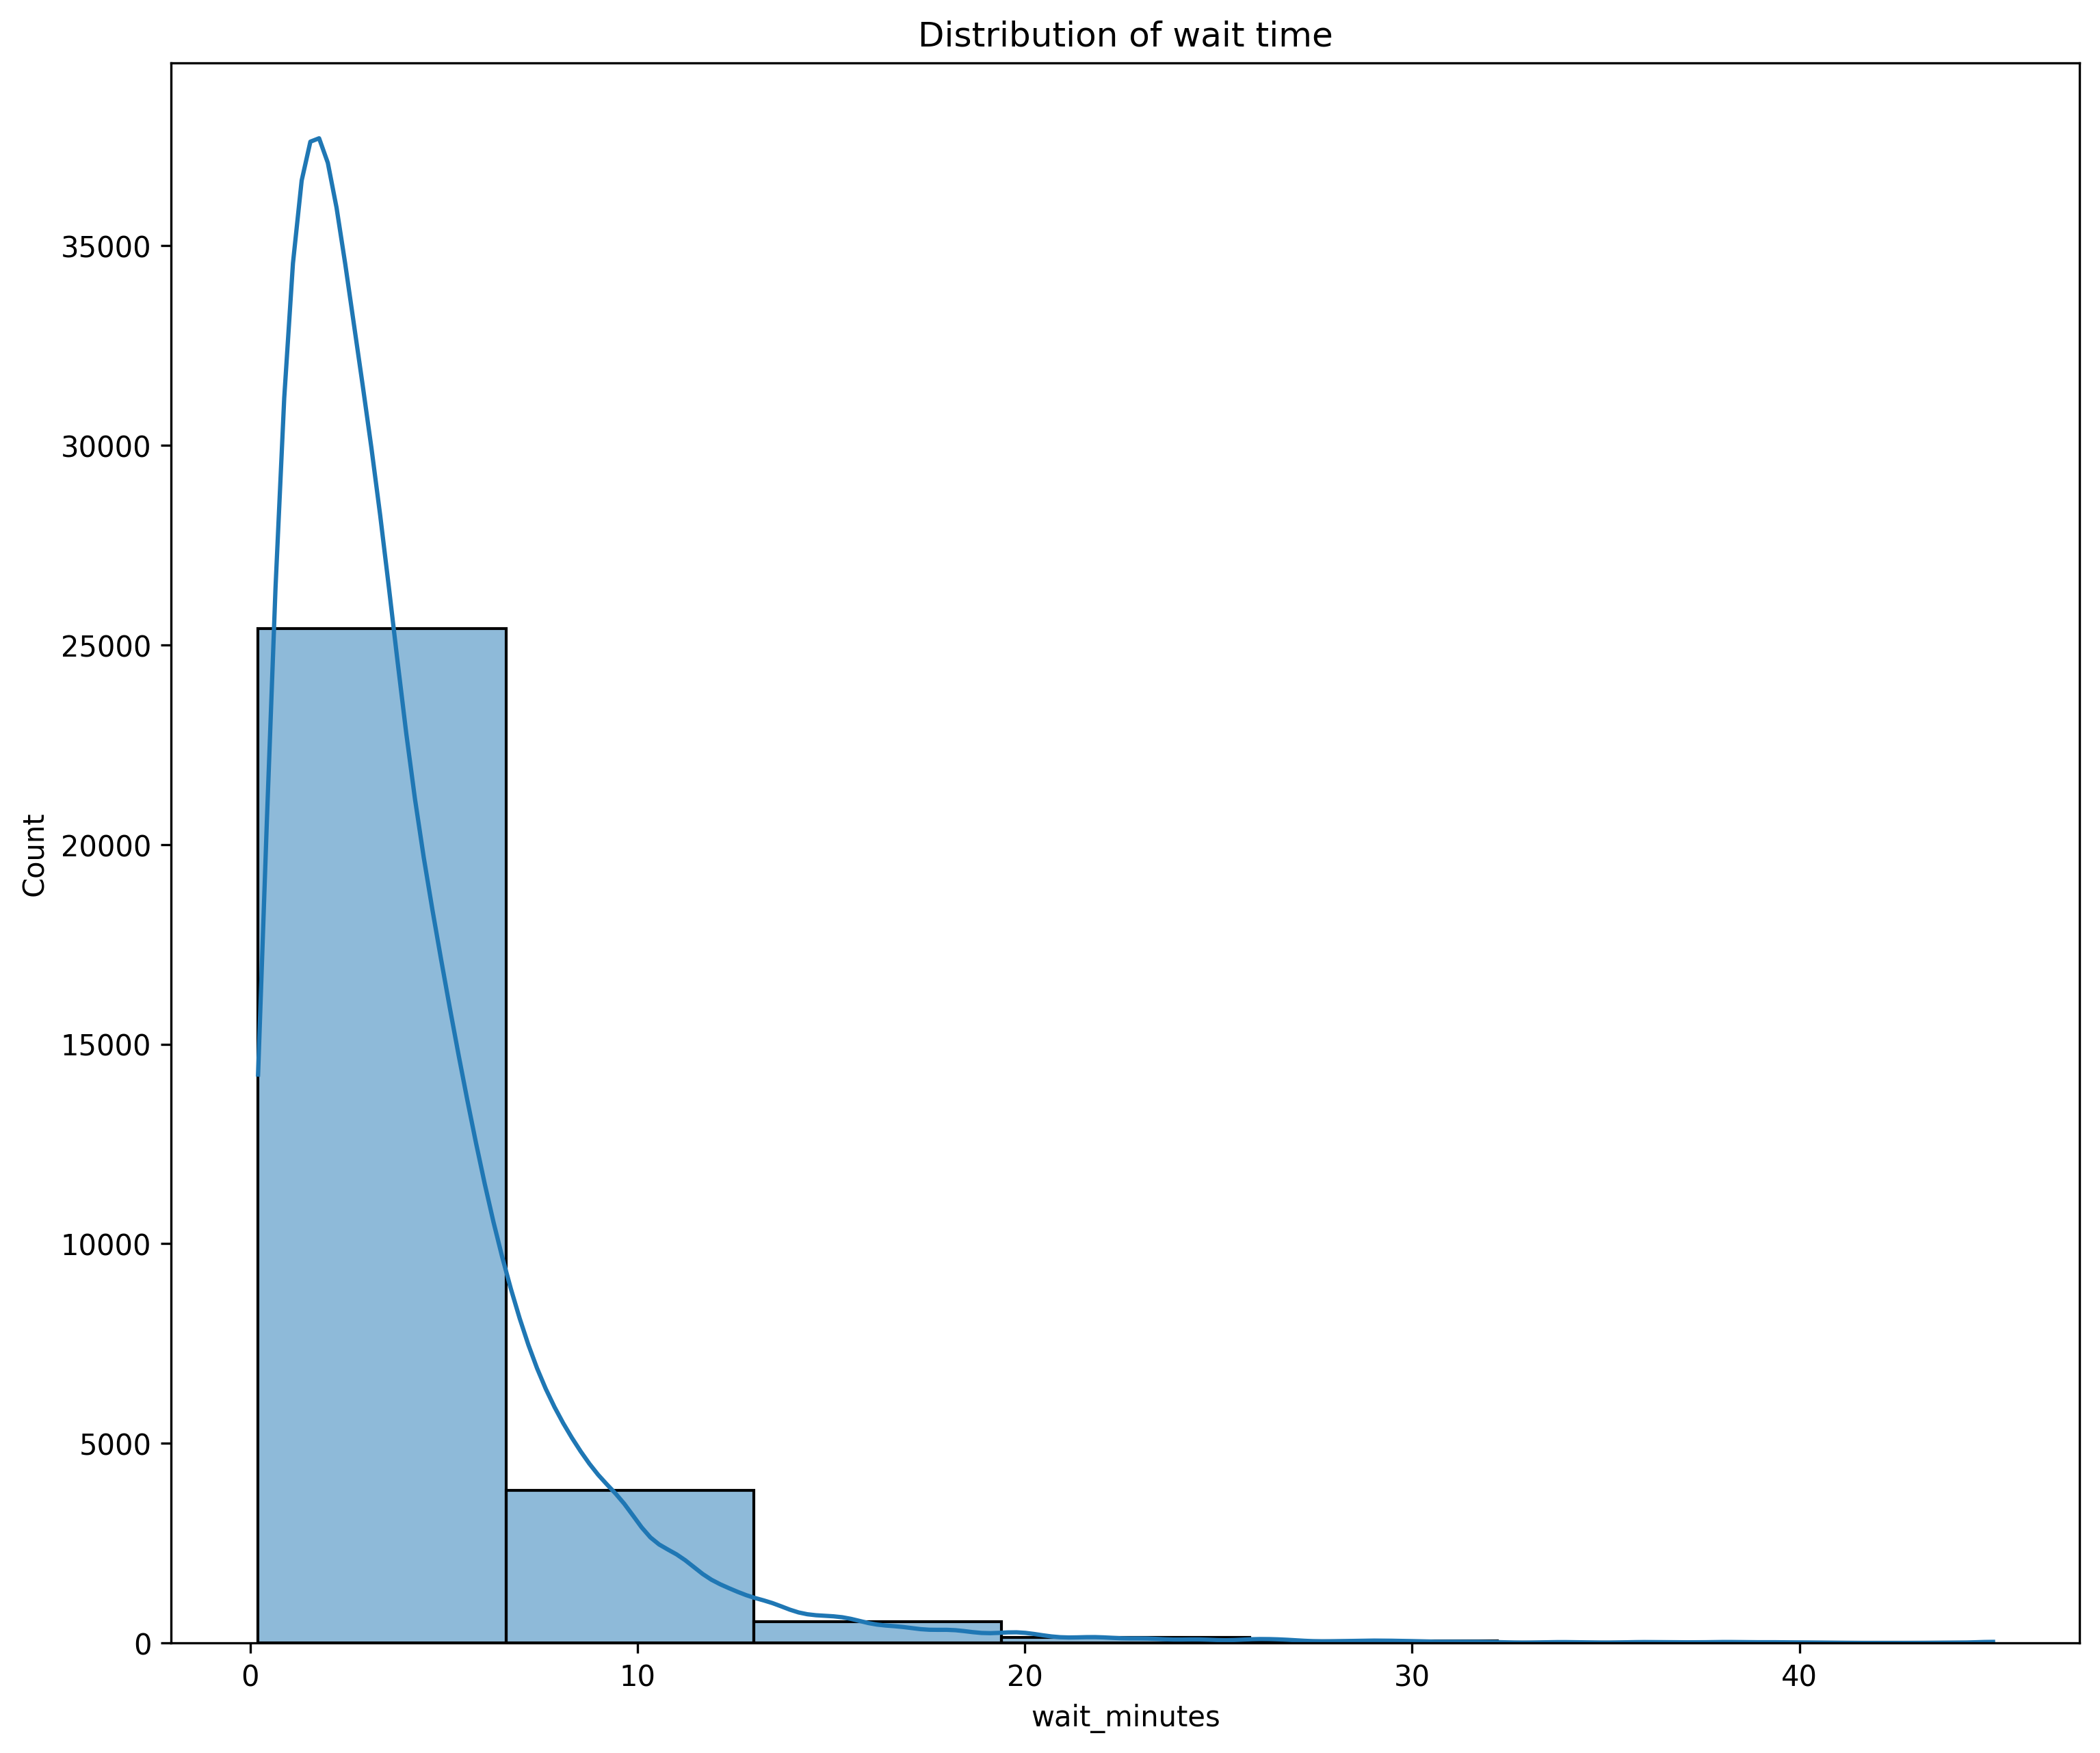

In [18]:
#distribution of wait time 
plt.figure(figsize=(12,10),dpi=300)
sns.histplot(transactions_df["wait_minutes"],bins=7,kde=True)
plt.title("Distribution of wait time")
plt.show()

In [19]:
#   Average wait time
avg_wait_time = transactions_df["wait_minutes"].mean()
print("Average wait_time in minutes:",round(avg_wait_time,2))

Average wait_time in minutes: 3.93


In [20]:
avg_wait_time = transactions_df["wait_minutes"].median()
print("Average wait_time in minutes:",round(avg_wait_time,2))

Average wait_time in minutes: 3.0


In [21]:
p50 = transactions_df["wait_minutes"].quantile(0.50)
print(f"P-50 of the data shows minutes: {p50}")

P-50 of the data shows minutes: 3.0


In [22]:
#Average swap duration
avg_swap_duration = transactions_df["swap_duration_minutes"].mean
print(f"Average swap duration in minutes: {avg_wait_time}")

Average swap duration in minutes: 3.0


In [23]:
corr = transactions_df[["swap_duration_minutes","wait_minutes"]].corr()

In [24]:
corr

,swap_duration_minutes,wait_minutes
swap_duration_minutes,1.000000,0.124164
wait_minutes,0.124164,1.000000


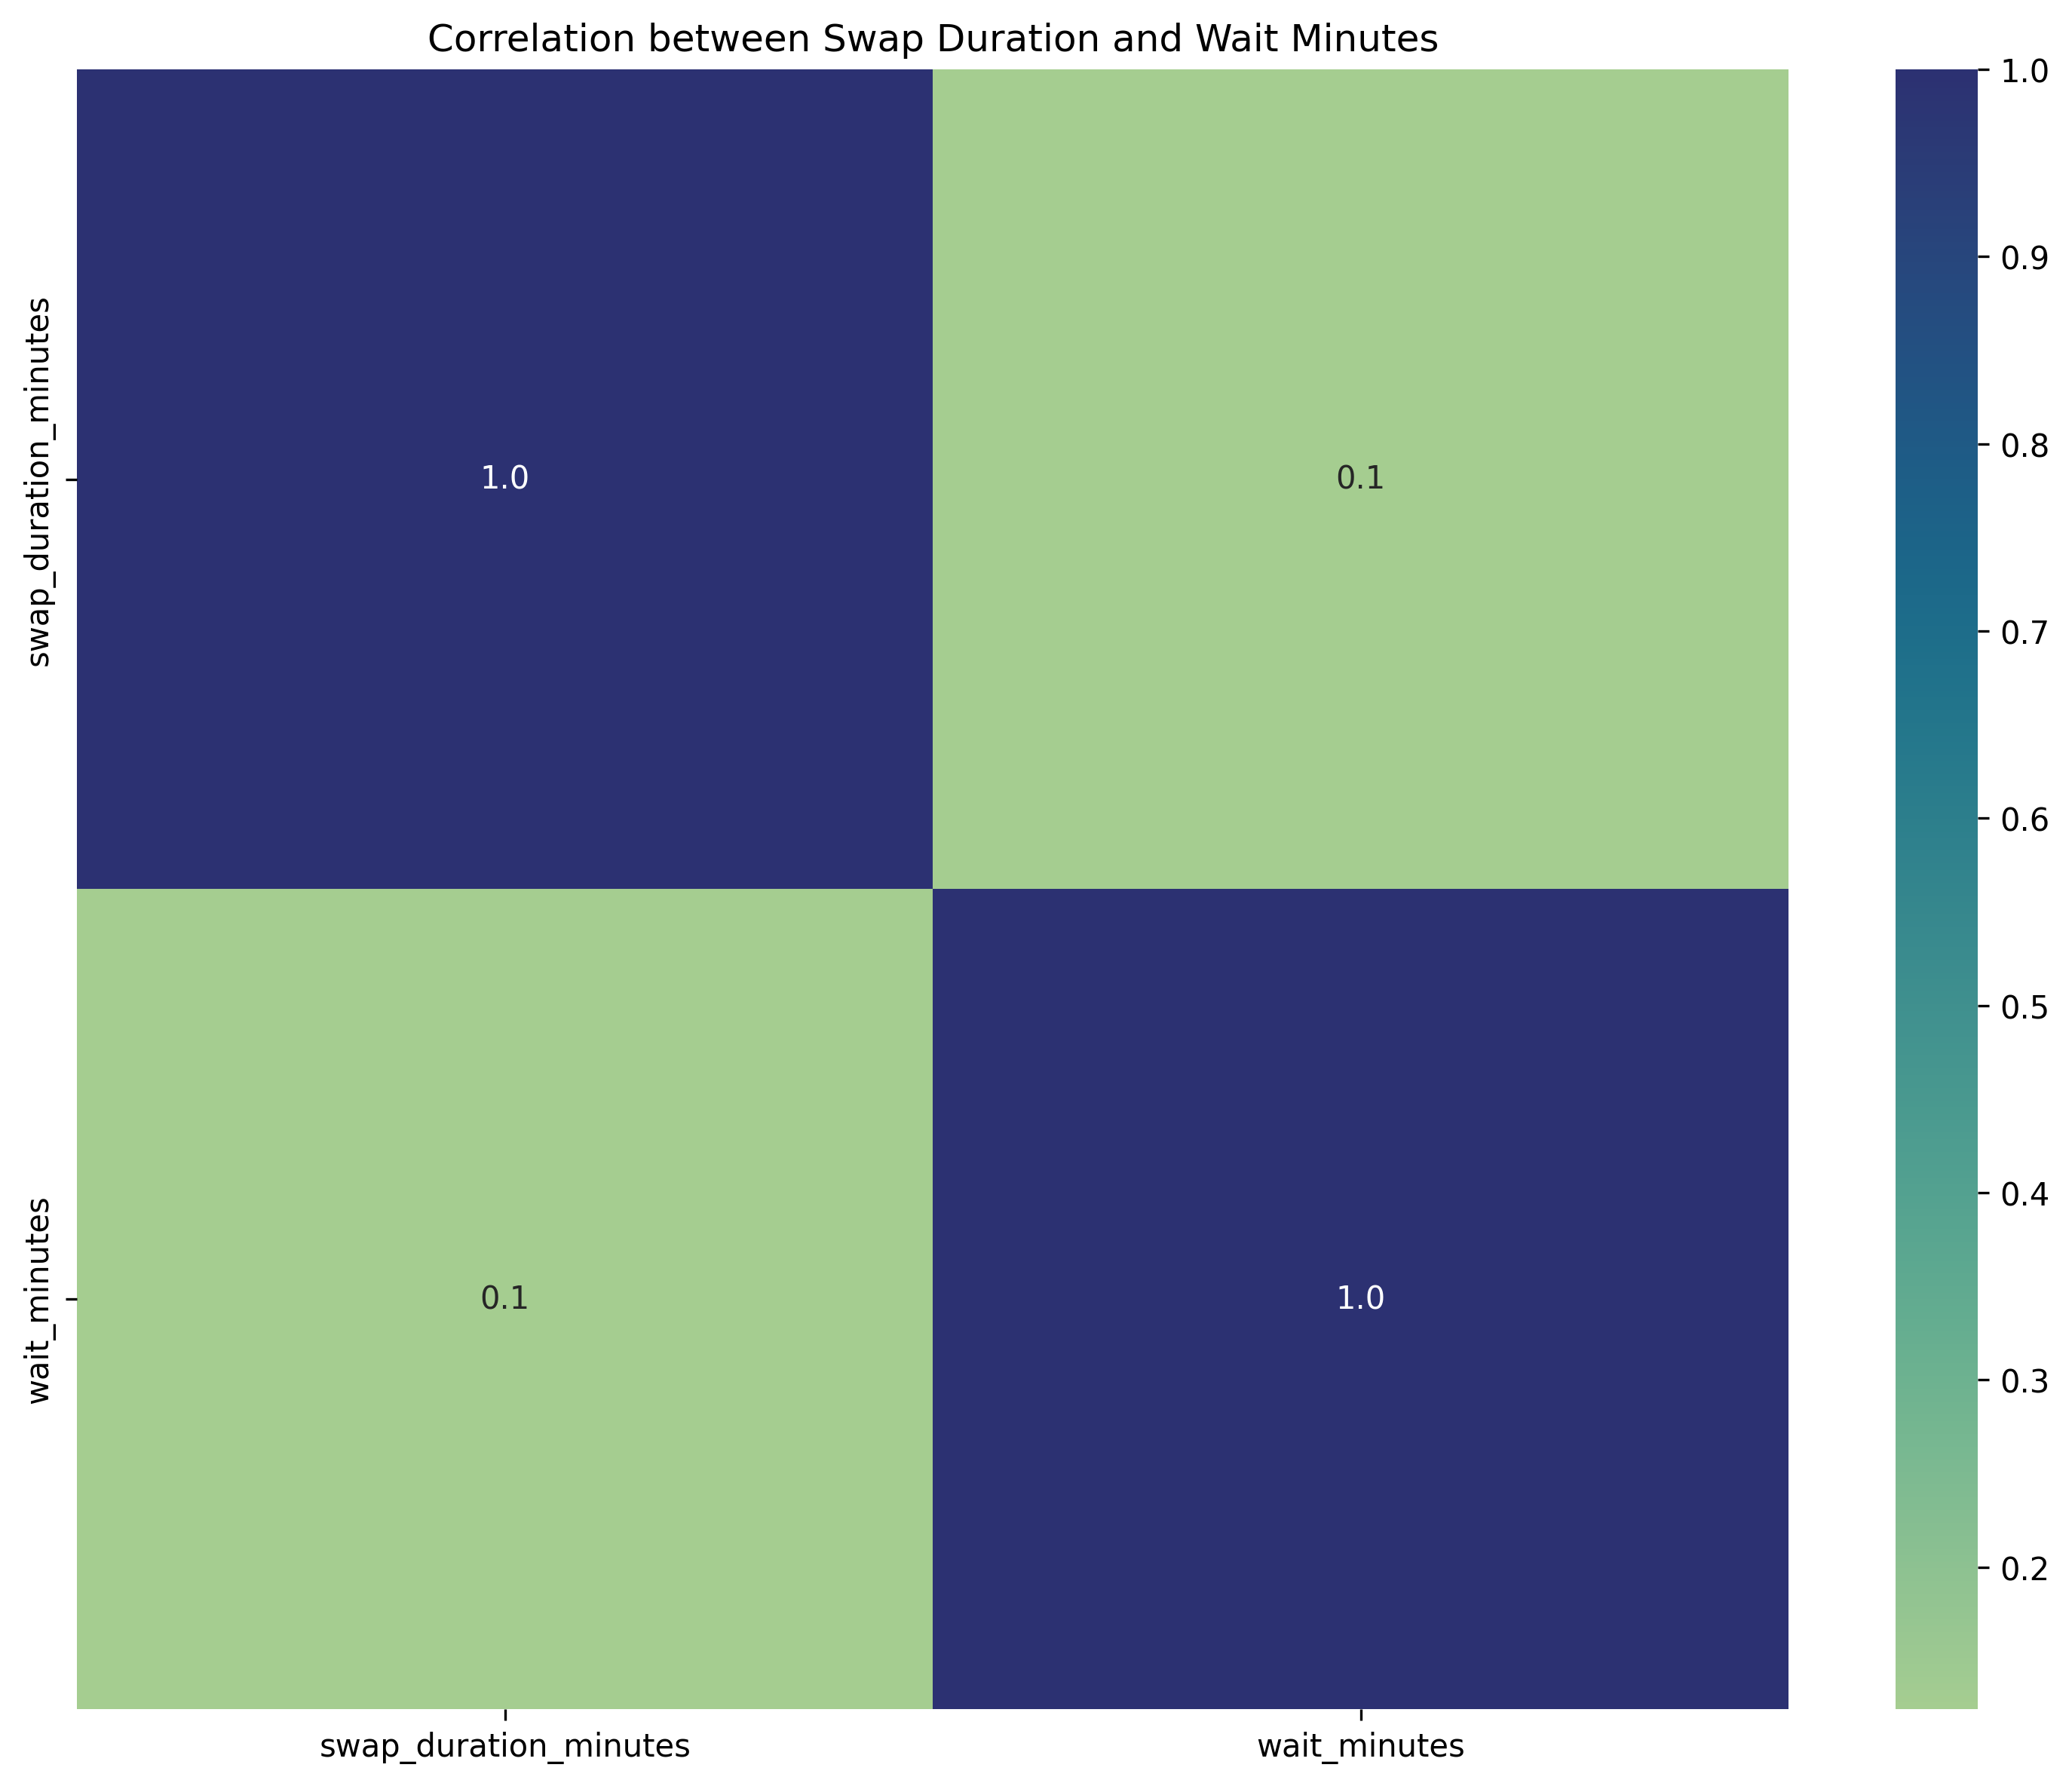

In [44]:
plt.figure(figsize=(10,8),dpi=300)
sns.heatmap(data=corr,cmap="crest",annot=True,fmt=".1f")
plt.title("Correlation between Swap Duration and Wait Minutes")
plt.tight_layout()
plt.show()

In [26]:
shortage_events = (transactions_df["batteries_available_before_swap"] <= 2).sum()

In [27]:
print(f"The battereies available are: {shortage_events} ")


The battereies available are: 1784 


In [28]:
shortage_rate = shortage_events / len(transactions_df) * 100
print("Shortage rate:",round(shortage_rate,2))

Shortage rate: 5.95


In [29]:
#Average downtime 
avg_downtime = transactions_df["downtime_minutes"].mean()
print("Average downtime:",round(avg_downtime,2))

Average downtime: 0.23


In [30]:
#Merging station datasets and swaps datasets
merged_df = pd.merge(df_swaps,transactions_df,on ="station_id",how="left")

In [31]:
merged_df

,station_id,station_name,district,latitude,longitude,capacity,opening_date,swap_id,timestamp,battery_soc_returned,...,downtime_minutes,payment_amount,payment_method,motorcycle_type,service_success,date,hour_number,hour,day,month
0,ST001,Adenta,Adenta Municipal,5.7049,-0.1682,24,2024-01-15,SW000001,2026-01-01 06:02:33,34.1,...,0,35.45,Mobile Money,Standard,True,2026-01-01,6,6 AM,Thursday,January
1,ST001,Adenta,Adenta Municipal,5.7049,-0.1682,24,2024-01-15,SW000011,2026-01-01 07:27:38,24.9,...,0,39.15,Mobile Money,Commercial,True,2026-01-01,7,7 AM,Thursday,January
2,ST001,Adenta,Adenta Municipal,5.7049,-0.1682,24,2024-01-15,SW000013,2026-01-01 07:32:13,21.6,...,0,38.83,Mobile Money,Commercial,True,2026-01-01,7,7 AM,Thursday,January
3,ST001,Adenta,Adenta Municipal,5.7049,-0.1682,24,2024-01-15,SW000021,2026-01-01 08:42:02,29.1,...,0,40.29,Mobile Money,Delivery,True,2026-01-01,8,8 AM,Thursday,January
4,ST001,Adenta,Adenta Municipal,5.7049,-0.1682,24,2024-01-15,SW000023,2026-01-01 08:47:28,24.7,...,0,40.74,Mobile Money,Commercial,True,2026-01-01,8,8 AM,Thursday,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,ST005,Abelenkpe,Ayawaso West,5.6096,-0.1967,20,2024-04-18,SW029945,2026-06-30 18:49:05,40.2,...,0,41.57,Mobile Money,Commercial,True,2026-06-30,18,6 PM,Tuesday,June
29996,ST005,Abelenkpe,Ayawaso West,5.6096,-0.1967,20,2024-04-18,SW029953,2026-06-30 19:24:01,25.6,...,0,35.52,Mobile Money,Standard,True,2026-06-30,19,7 PM,Tuesday,June
29997,ST005,Abelenkpe,Ayawaso West,5.6096,-0.1967,20,2024-04-18,SW029968,2026-06-30 20:02:25,4.4,...,0,37.97,Mobile Money,Delivery,True,2026-06-30,20,8 PM,Tuesday,June
29998,ST005,Abelenkpe,Ayawaso West,5.6096,-0.1967,20,2024-04-18,SW029980,2026-06-30 20:49:56,19.6,...,0,33.90,Card,Standard,True,2026-06-30,20,8 PM,Tuesday,June


In [32]:
busiest_station = (merged_df.groupby("station_name")["swap_id"].count().sort_values(ascending=False))
print("The statiions with most swaps:",busiest_station)

The statiions with most swaps: station_name
Adenta       7912
Spintex      6921
Kaneshie     6196
Haatso       4945
Abelenkpe    4026
Name: swap_id, dtype: int64


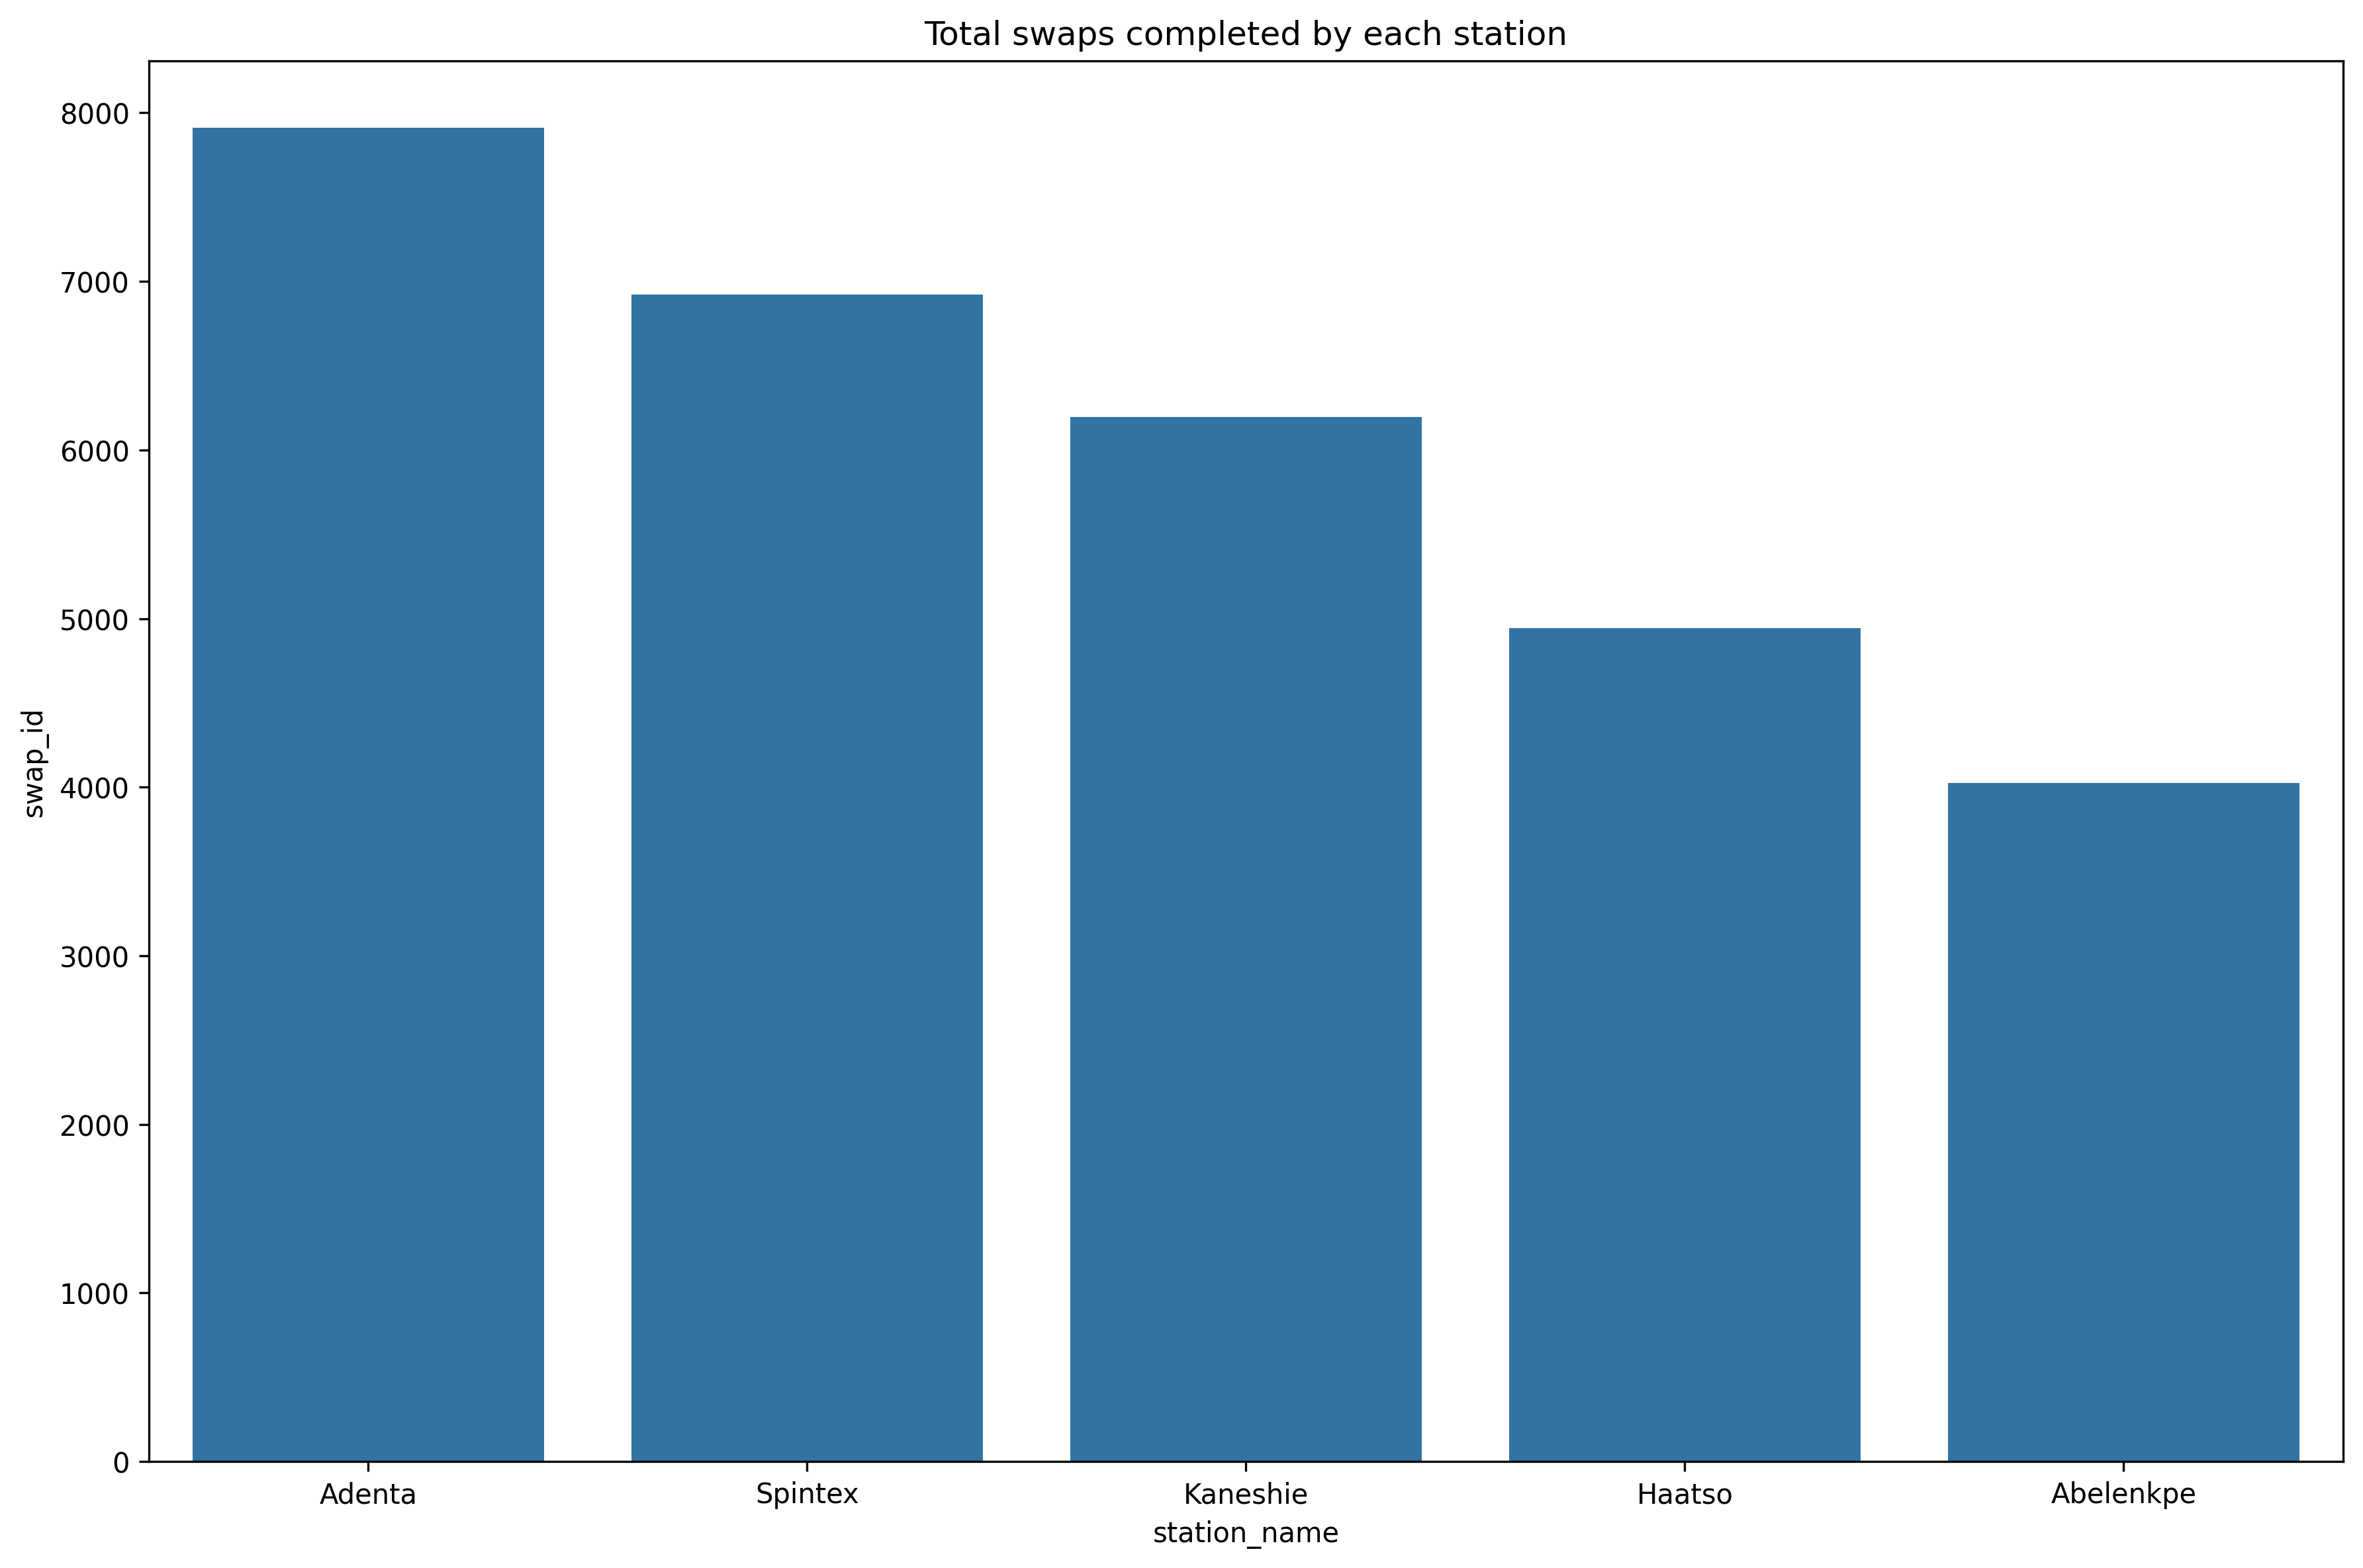

In [45]:

plt.figure(figsize=(12,8),dpi=300)
sns.barplot(data=busiest_station)
plt.xlabel("station_name")
plt.title("Total swaps completed by each station")
plt.ylabel("swap_id")
plt.tight_layout()
plt.show()

In [34]:
peak_period = transactions_df.groupby("hour")["swap_id"].count()
peak_period

hour
1 AM      145
1 PM     1302
10 AM    1266
10 PM     901
11 AM    1217
11 PM     491
12 AM     203
12 PM    1214
2 AM      108
2 PM     1261
3 AM       97
3 PM     1333
4 AM      123
4 PM     1676
5 AM      211
5 PM     2262
6 AM      778
6 PM     2880
7 AM     1642
7 PM     3050
8 AM     2139
8 PM     2478
9 AM     1722
9 PM     1501
Name: swap_id, dtype: int64

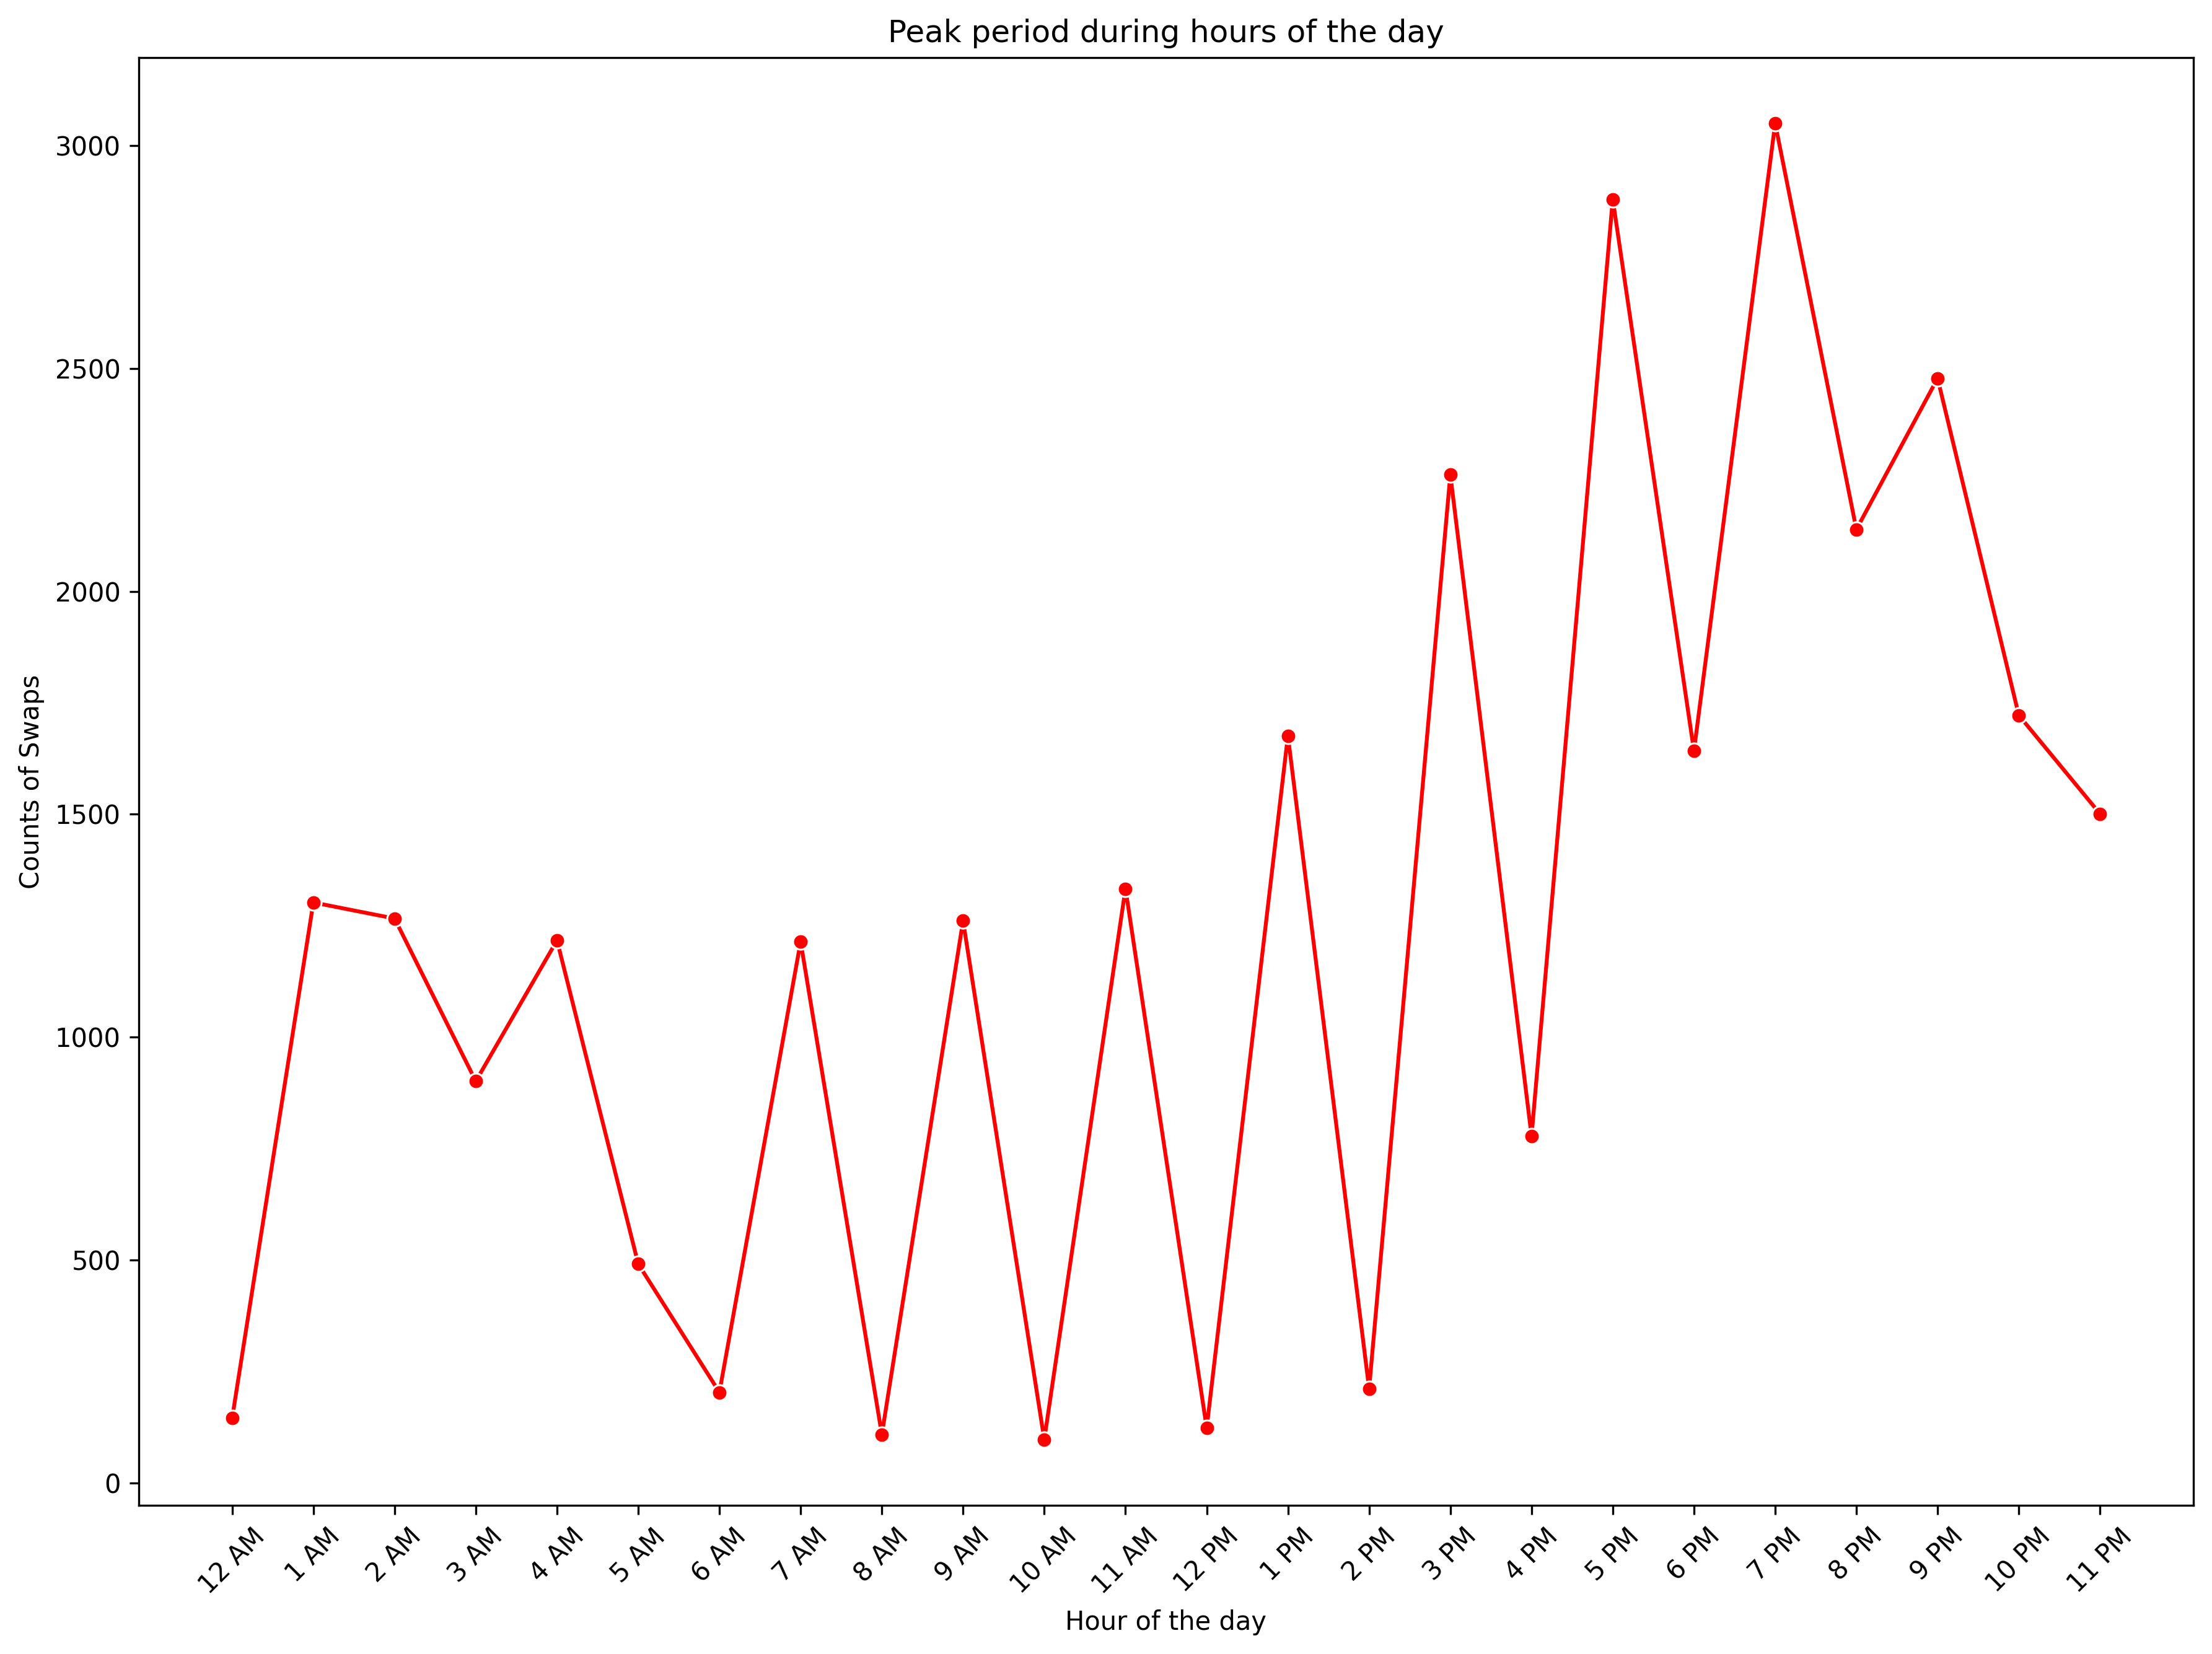

In [42]:
plt.figure(figsize=(12,9),dpi=300)
sns.lineplot(data=peak_period,marker="o",color="red")
plt.xlabel("Hour of the day")
plt.ylabel("Counts of Swaps")
plt.title("Peak period during hours of the day")
plt.xticks(
    range(24),
    hour_labels,
    rotation=45
)
plt.tight_layout()
plt.show()

In [36]:
#Peak days
peak_days = (transactions_df.groupby("day")["swap_id"].count().sort_values(ascending=False)) 
peak_days

day
Friday       4705
Monday       4636
Tuesday      4600
Thursday     4577
Wednesday    4408
Saturday     3543
Sunday       3531
Name: swap_id, dtype: int64

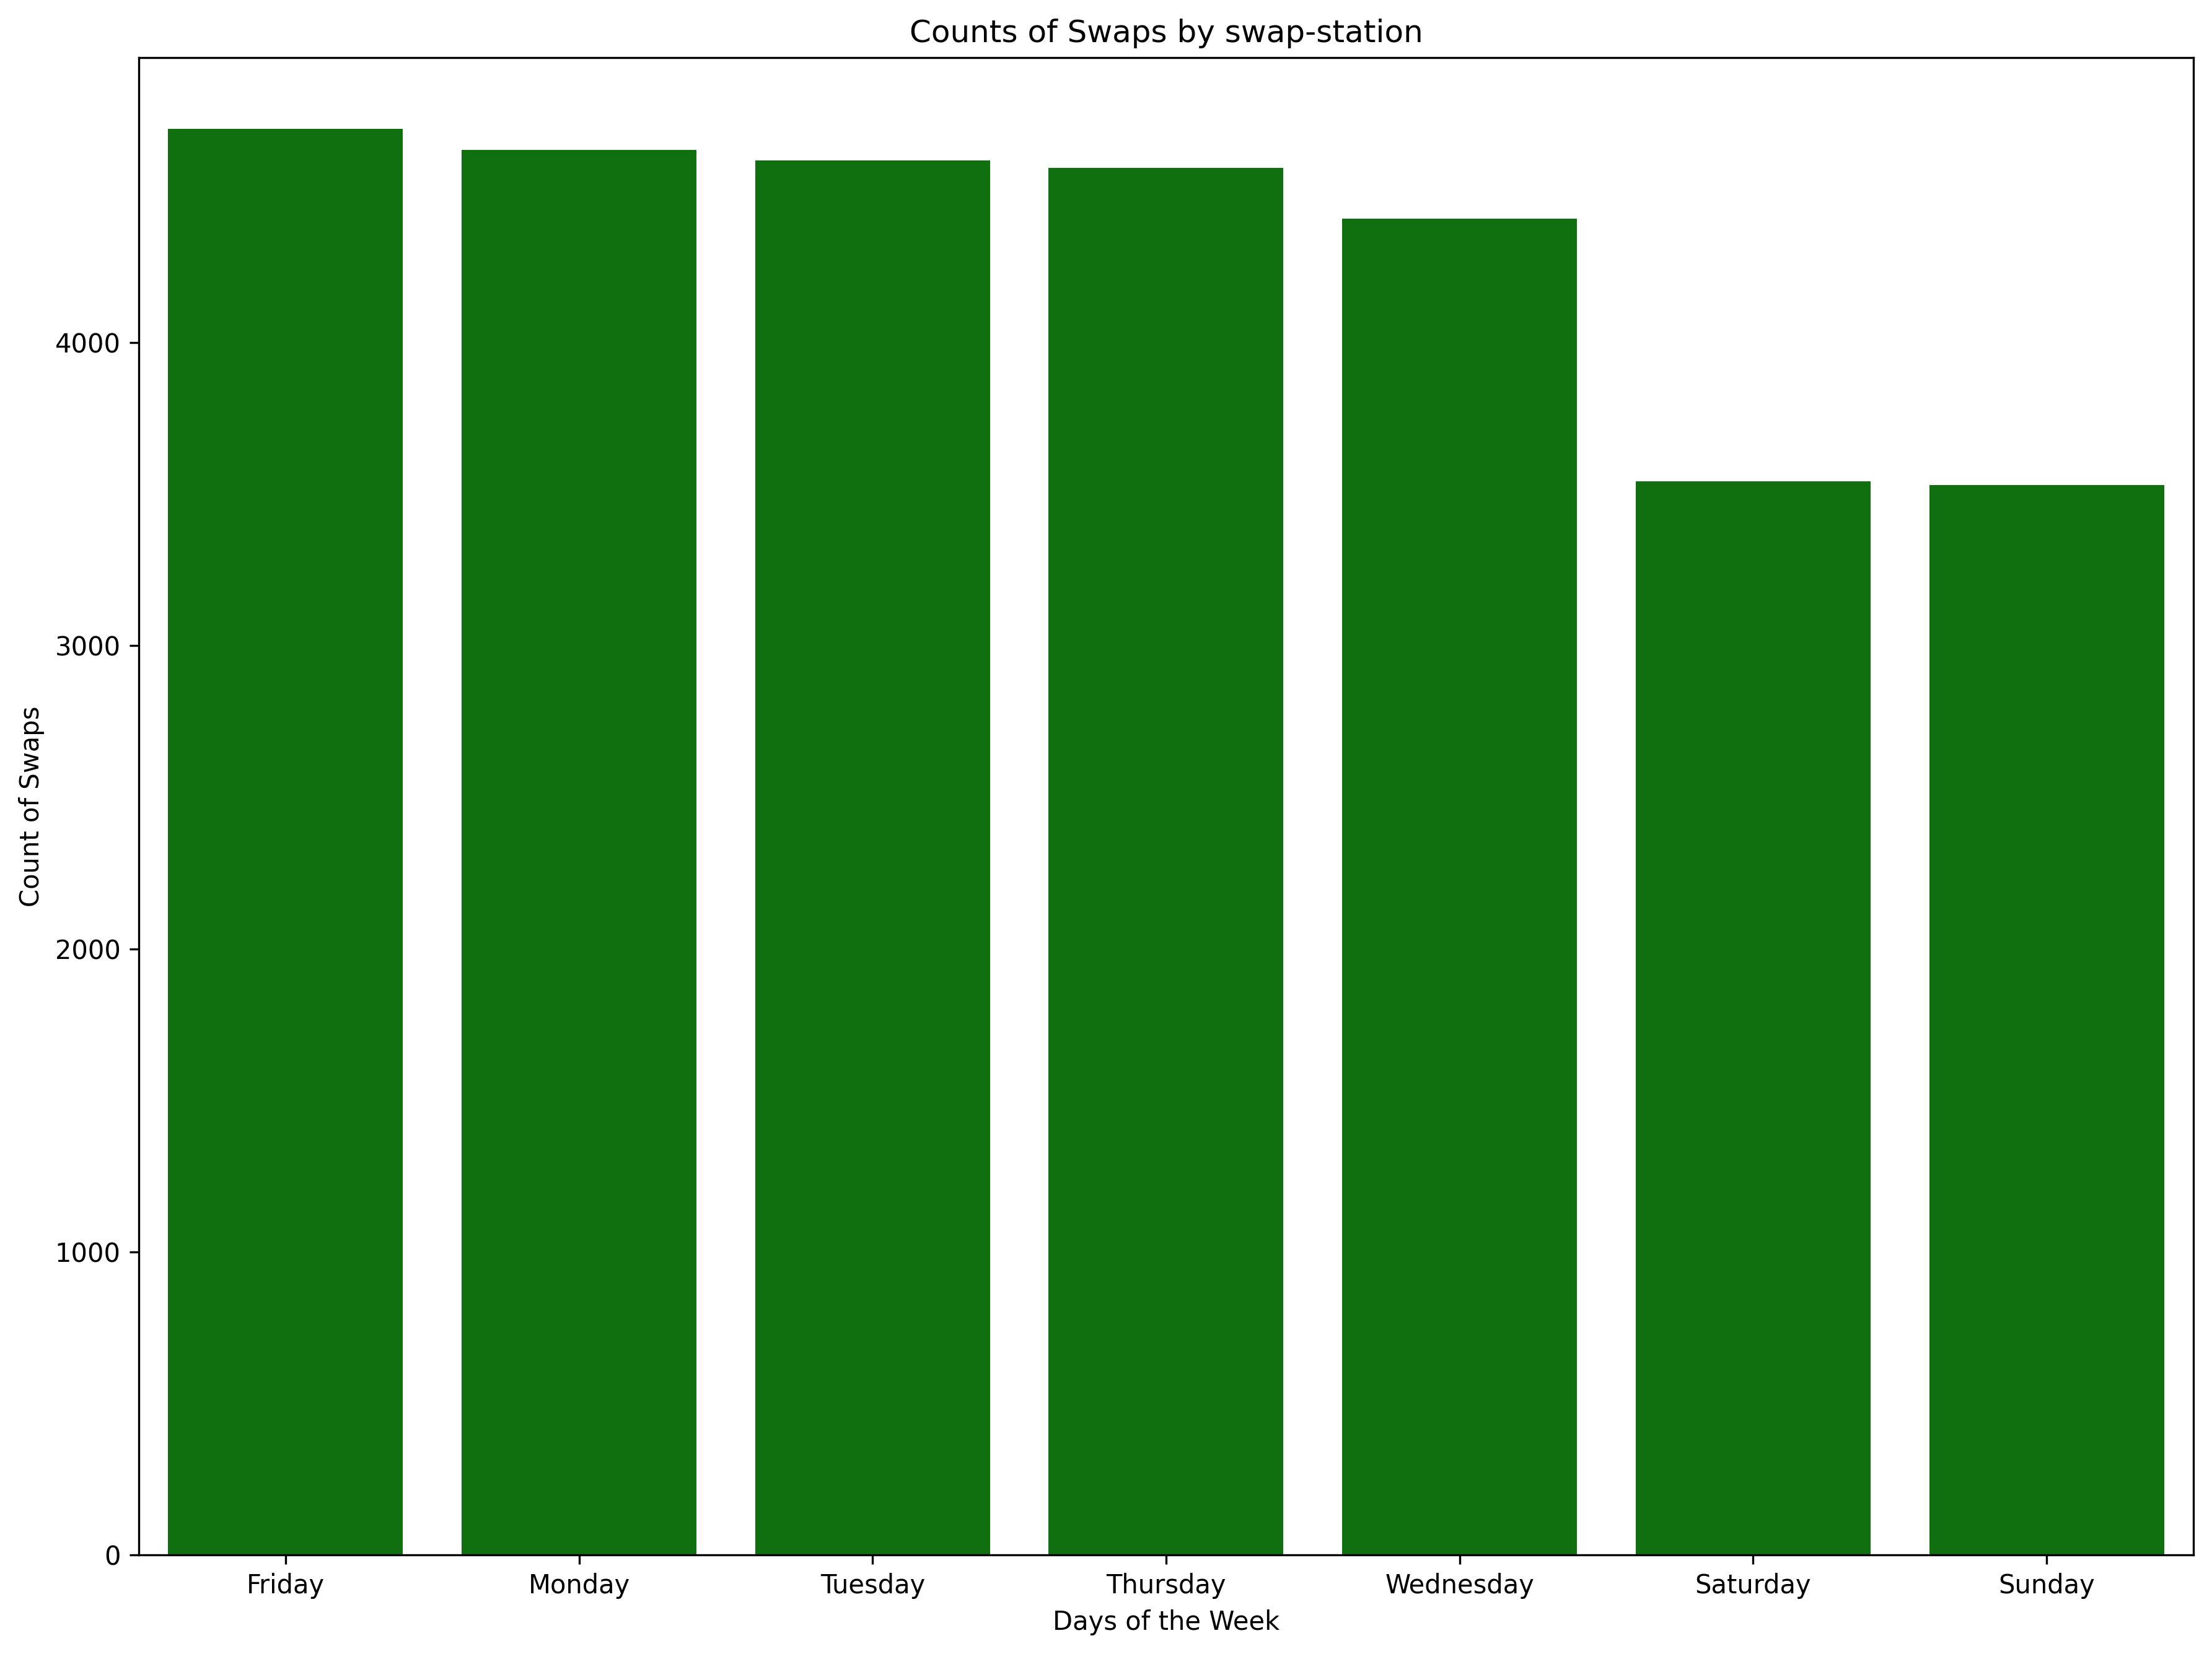

In [46]:
plt.figure(figsize=(12,9),dpi=300)
sns.barplot(data=peak_days,color = "green")
plt.xlabel("Days of the Week")
plt.ylabel("Count of Swaps")
plt.title("Counts of Swaps by swap-station")
plt.tight_layout()
plt.show()


In [38]:
#peak time at each station 

station_peak = merged_df.groupby(["hour","station_name"]).size().reset_index(name="swap_id")
print(station_peak.head(3))

   hour station_name  swap_id
0  1 AM    Abelenkpe       20
1  1 AM       Adenta       42
2  1 AM       Haatso       26


In [39]:
station_peak_mat = station_peak.pivot(index="station_name",columns="hour",values="swap_id")
station_peak_mat

hour,1 AM,1 PM,10 AM,10 PM,11 AM,11 PM,12 AM,12 PM,2 AM,2 PM,...,5 AM,5 PM,6 AM,6 PM,7 AM,7 PM,8 AM,8 PM,9 AM,9 PM
station_name,,,,,,,,,,,,,,,,,,,,,
Abelenkpe,20,203,189,106,153,57,29,167,13,178,...,29,271,119,386,214,405,282,331,227,209
Adenta,42,345,359,225,331,123,54,292,27,341,...,68,580,175,803,426,807,552,656,467,391
Haatso,26,225,189,145,213,77,29,204,25,208,...,33,405,133,440,281,533,364,390,287,234
Kaneshie,25,242,253,196,251,109,51,274,17,247,...,29,481,148,581,336,589,438,522,375,330
Spintex,32,287,276,229,269,125,40,277,26,287,...,52,525,203,670,385,716,503,579,366,337


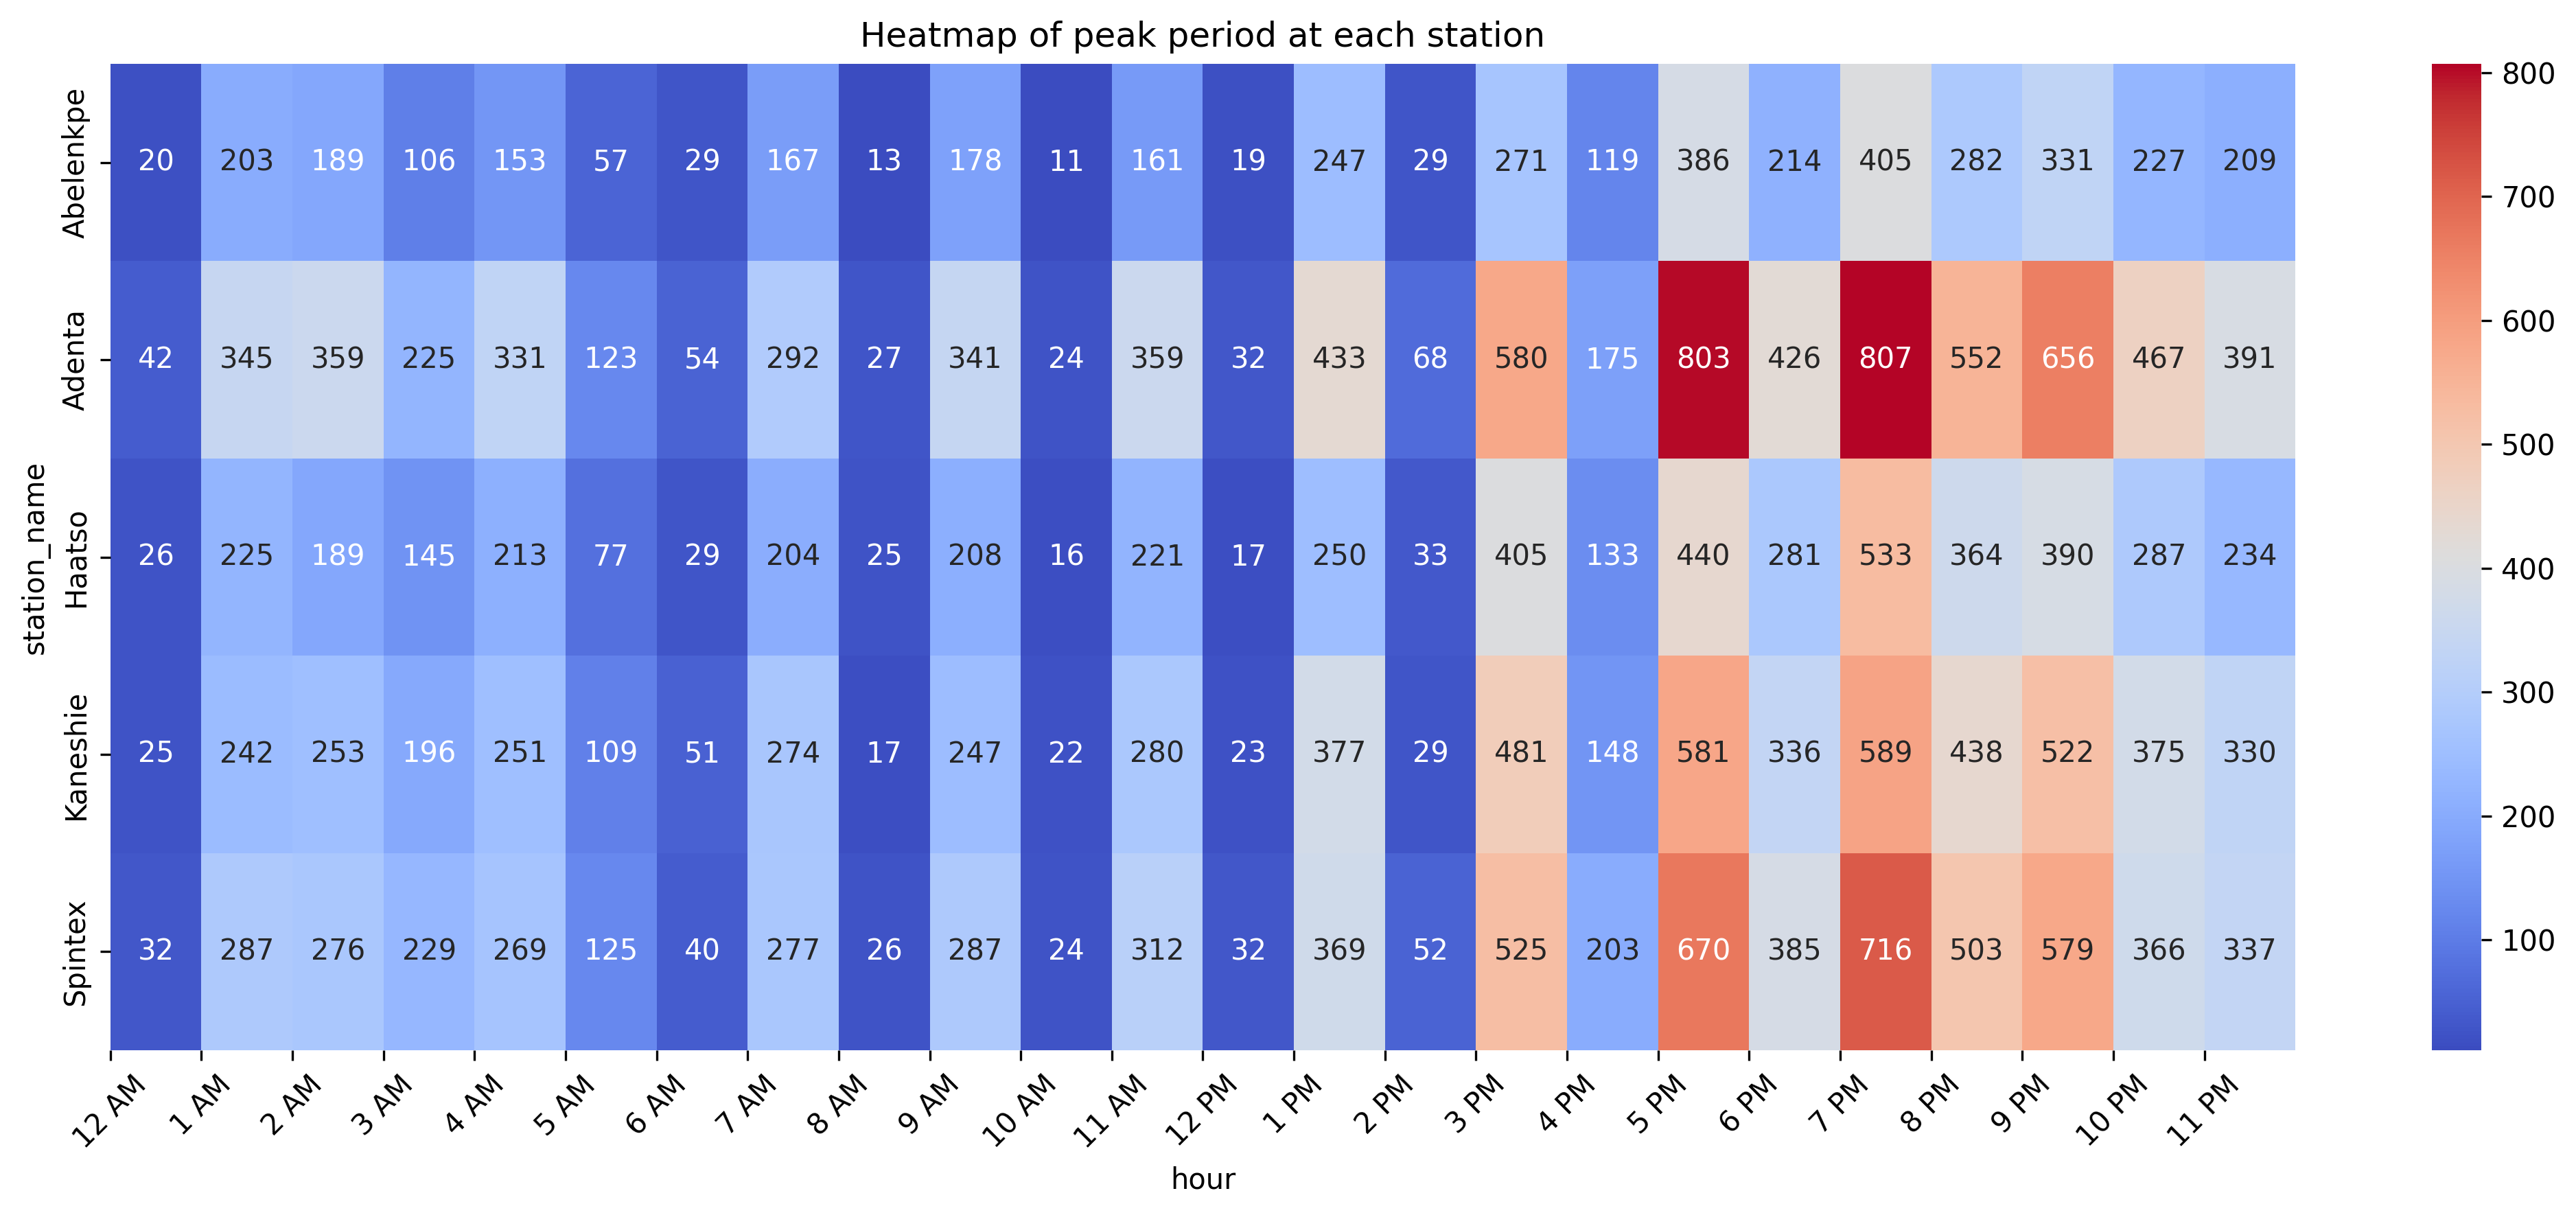

In [43]:
plt.figure(figsize=(14,6),dpi=300)
sns.heatmap(data=station_peak_mat,cmap="coolwarm",annot=True,cbar=True,fmt=".0f")
plt.title("Heatmap of peak period at each station")
plt.xticks(
    range(24),
    hour_labels,
    rotation=45
)
plt.tight_layout()
plt.show()